### Exploratory Data Analysis (EDA) on Amazon Product Reviews

This notebook explores the Amazon Product Reviews Dataset to understand rating distributions, review length trends, verified purchase effects, and correlations between numerical features. It identifies key patterns such as positive bias in ratings, longer negative reviews, and weak correlation between rating and helpfulness. The insights guide further sentiment analysis and model development.

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when, isnan, isnull, mean, stddev, min, max, length
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DateType
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
# Initialize Spark Session
spark = SparkSession.builder \
    .appName("Amazon Reviews EDA") \
    .config("spark.executor.memory", "4g") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

In [3]:
reviews_df = spark.read.parquet("gs://final-project-bucket-amazon/processed/all_reviews.parquet")
print(f"Loaded {reviews_df.count()} reviews from parquet")

Loaded 18118476 reviews from parquet


In [18]:
# View first few rows of the dataset
reviews_df.show(2)

+-----------+-----------+--------------+----------+--------------+--------------------+----------------+-----------+-------------+-----------+----+-----------------+--------------------+--------------------+-----------+------------------+
|marketplace|customer_id|     review_id|product_id|product_parent|       product_title|product_category|star_rating|helpful_votes|total_votes|vine|verified_purchase|     review_headline|         review_body|review_date|     helpful_ratio|
+-----------+-----------+--------------+----------+--------------+--------------------+----------------+-----------+-------------+-----------+----+-----------------+--------------------+--------------------+-----------+------------------+
|         US|   51187967|R3UE1NIEC0LNPD|078942052X|     428637498|The Amazing Pull-...|           Books|          3|           40|         42|   N|                N|More of a Poster ...|This is not a boo...| 1999-12-11|0.9523809523809523|
|         US|   50547216| RPEX7APLGS3MM|0553

In [5]:
# Check for null values in each column
print("Null values by column:")
null_counts = reviews_df.select([count(when(col(c).isNull(), c)).alias(c) for c in reviews_df.columns])
null_counts.show()

Null values by column:
+-----------+-----------+---------+----------+--------------+-------------+----------------+-----------+-------------+-----------+----+-----------------+---------------+-----------+-----------+-------------+
|marketplace|customer_id|review_id|product_id|product_parent|product_title|product_category|star_rating|helpful_votes|total_votes|vine|verified_purchase|review_headline|review_body|review_date|helpful_ratio|
+-----------+-----------+---------+----------+--------------+-------------+----------------+-----------+-------------+-----------+----+-----------------+---------------+-----------+-----------+-------------+
|          0|          0|        0|         0|             0|            0|               0|          0|            0|          0|   0|                0|              0|          0|          0|      9729685|
+-----------+-----------+---------+----------+--------------+-------------+----------------+-----------+-------------+-----------+----+----------

The dataset has no missing values in any column except for the helpful_ratio column, which has about 9.7 million missing values. This is expected since the helpful_ratio is derived from helpful_votes / total_votes, and many reviews have no votes.

In [6]:
# Distribution of star ratings
print("Distribution of star ratings:")
star_distribution = reviews_df.groupBy("star_rating").count().orderBy("star_rating")
star_distribution.show()

Distribution of star ratings:
+-----------+--------+
|star_rating|   count|
+-----------+--------+
|          1| 1589598|
|          2| 1030353|
|          3| 1593683|
|          4| 3183428|
|          5|10721414|
+-----------+--------+



The majority of reviews have 5-star ratings, followed by 4-star ratings. Negative ratings (1 and 2 stars) are significantly lower, indicating a general bias towards positive reviews in the dataset.

In [7]:
# Statistical summary of numeric columns
print("Statistical summary of numerical columns:")
reviews_df.select("star_rating", "helpful_votes", "total_votes").summary("count", "min", "25%", "mean", "75%", "max").show()

Statistical summary of numerical columns:
+-------+-----------------+-----------------+------------------+
|summary|      star_rating|    helpful_votes|       total_votes|
+-------+-----------------+-----------------+------------------+
|  count|         18118476|         18118476|          18118476|
|    min|                1|                0|                 0|
|    25%|                4|                0|                 0|
|   mean|4.126844608784977|2.829751519940198|3.6521959131662065|
|    75%|                5|                2|                 2|
|    max|                5|            41278|             41889|
+-------+-----------------+-----------------+------------------+



Most reviews receive very few helpful votes, with the 75th percentile having only 2 helpful votes.
There are some extreme values in helpful_votes and total_votes, indicating the presence of influential reviews with a high number of votes.

In [8]:
# Calculating mean and standard deviation for numerical columns
print("Mean and standard deviation for numerical features:")
numerical_stats = reviews_df.select([
    mean("star_rating").alias("mean_star_rating"),
    stddev("star_rating").alias("stddev_star_rating"),
    mean("helpful_votes").alias("mean_helpful_votes"),
    stddev("helpful_votes").alias("stddev_helpful_votes"),
    mean("total_votes").alias("mean_total_votes"),
    stddev("total_votes").alias("stddev_total_votes")
])
numerical_stats.show()

Mean and standard deviation for numerical features:
+-----------------+------------------+------------------+--------------------+------------------+------------------+
| mean_star_rating|stddev_star_rating|mean_helpful_votes|stddev_helpful_votes|  mean_total_votes|stddev_total_votes|
+-----------------+------------------+------------------+--------------------+------------------+------------------+
|4.126844608784977|1.2964107316375937| 2.829751519940198|  21.071730487542393|3.6521959131662065| 22.81172270059602|
+-----------------+------------------+------------------+--------------------+------------------+------------------+



- Star ratings have a low standard deviation (~1.29), meaning most ratings are concentrated around 4-5 stars
- Helpfulness votes and total votes have high standard deviations, confirming the presence of reviews with exceptionally high engagement.

In [9]:
# Check for outliers in helpful_votes and total_votes
print("Potential outliers in helpful_votes:")
outliers_helpful = reviews_df.filter(col("helpful_votes") > 100).orderBy(col("helpful_votes").desc())
outliers_helpful.select("product_category", "star_rating", "helpful_votes", "total_votes").show(10)

Potential outliers in helpful_votes:
+----------------+-----------+-------------+-----------+
|product_category|star_rating|helpful_votes|total_votes|
+----------------+-----------+-------------+-----------+
|         Apparel|          5|        41278|      41889|
|           Books|          5|        15835|      16352|
|          Beauty|          1|        13362|      13636|
|     Electronics|          3|        12786|      12944|
|         Apparel|          5|        11350|      11728|
|         Apparel|          5|        11219|      11555|
|          Beauty|          4|        10265|      10374|
|     Electronics|          1|         8937|       9072|
|     Electronics|          5|         8421|       8680|
|         Apparel|          5|         6894|       7615|
+----------------+-----------+-------------+-----------+
only showing top 10 rows



Certain reviews, particularly in categories like Apparel, Books, Beauty, and Electronics, have extremely high helpful votes (e.g., 41,278 helpful votes for a single review). These could represent highly impactful reviews or possible anomalies.

In [10]:
# Distribution of verified purchases
print("Verified purchase distribution:")
verified_distribution = reviews_df.groupBy("verified_purchase").count().orderBy("verified_purchase")
verified_distribution.show()

Verified purchase distribution:
+-----------------+--------+
|verified_purchase|   count|
+-----------------+--------+
|                N| 4939153|
|                Y|13179323|
+-----------------+--------+



Over 72% of reviews are from verified purchases, adding credibility to the dataset.However, a significant portion (27%) are unverified, which might contain unreliable or manipulated reviews.

In [11]:
# Analysis of helpful ratio (helpful_votes/total_votes)
from pyspark.sql.functions import when, col
reviews_df = reviews_df.withColumn(
    "helpful_ratio", 
    when(col("total_votes") > 0, col("helpful_votes") / col("total_votes")).otherwise(None)
)
print("Helpful ratio statistics:")
reviews_df.select("helpful_ratio").summary("count", "min", "mean", "max").show()

Helpful ratio statistics:
+-------+------------------+
|summary|     helpful_ratio|
+-------+------------------+
|  count|           8388791|
|    min|               0.0|
|   mean|0.7310621604929004|
|    max|               1.0|
+-------+------------------+



The average helpful ratio is ~0.73, meaning most users agree with the helpfulness votes given to reviews.
Some reviews have 0 helpfulness, indicating they received votes but were not marked helpful at all.

In [12]:
# Correlation between star_rating and helpful_ratio
from pyspark.sql.functions import corr
correlation = reviews_df.select(corr("star_rating", "helpful_ratio"))
print("Correlation between star rating and helpful ratio:")
correlation.show()

Correlation between star rating and helpful ratio:
+--------------------------------+
|corr(star_rating, helpful_ratio)|
+--------------------------------+
|             0.19745595057667906|
+--------------------------------+



The correlation between star ratings and helpfulness ratio is ~0.19, which is weak.This suggests that higher star ratings do not necessarily mean the review is considered helpful by other users.

In [13]:
# Check for any problematic reviews (e.g., empty review body but with ratings)
print("Counting reviews with missing content:")
empty_reviews = reviews_df.filter(
    (col("review_body").isNull()) | (length(col("review_body")) < 5)
).count()
print(f"Number of reviews with missing or very short content: {empty_reviews}")

Counting reviews with missing content:
Number of reviews with missing or very short content: 144412


Around 144,412 reviews have either missing or extremely short content.
These reviews may not be useful for sentiment analysis, and we might consider removing them.

In [14]:
# Convert a sample to pandas for visualization. Only converting a sample to avoid memory issues
sample_df = reviews_df.sample(fraction=0.01, seed=42).toPandas()

In [21]:
sample_df.head()

,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date,helpful_ratio,review_length
0,US,51245574,R3UPFGCAANS6DW,0925162221,655140552,"Ballet, Tap and All That Jazz",Books,1,4,5,N,N,Parent of a young dancer,This &quot;book&quot; is primarily a catalogue...,1999-12-11,0.8,305
1,US,50548708,R1PJ2E1ERU2DSM,0961684402,104708972,The Adventures of Mabel,Books,5,7,7,N,N,The Adventures of Mabel,"This story was read to me in 2nd grade, and I ...",1999-12-11,1.0,482
2,US,50640933,R1NGZ0R4364JNI,0967746906,46323685,Chocolate Covered Bananas,Books,5,0,0,N,N,Who knew chocolate could be so good for kids!,This is one of the most delightful books we ha...,1999-12-11,NaN,403
3,US,50543514,RO0U9BUZZEUNH,0553110616,737842842,House Atreides (Dune: House Trilogy Book 1),Books,5,2,5,N,N,"It's not Dune, but that doesn't mean it isn't ...","Having read most of the previous reviews, it s...",1999-12-11,0.4,975
4,US,52500757,R2K7DHVBF9A152,0440431808,646438686,From the Mixed-Up Files of Mrs. Basil E. Frank...,Books,5,6,6,N,N,Best Ever,"This book was really, really good. Most books ...",1999-12-11,1.0,538


/opt/conda/anaconda/lib/python3.7/site-packages/ipykernel_launcher.py:18: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

/opt/conda/anaconda/lib/python3.7/site-packages/ipykernel_launcher.py:26: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751



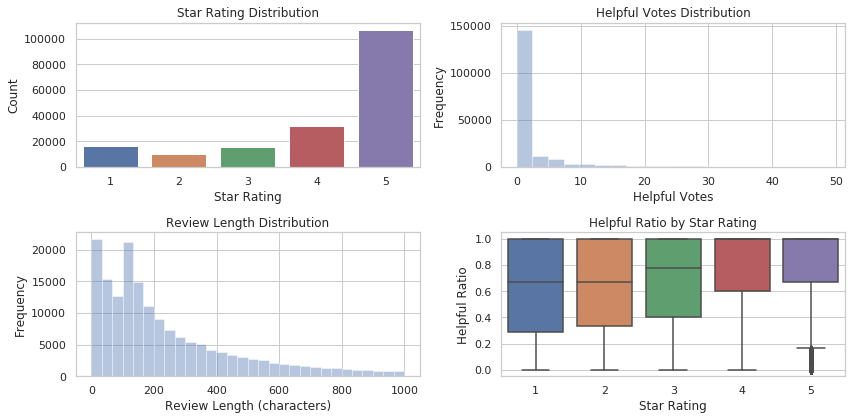

Copying file:///tmp/amazon_reviews_eda.png [Content-Type=image/png]...
/ [1 files][ 35.5 KiB/ 35.5 KiB]                                                
Operation completed over 1 objects/35.5 KiB.                                     


In [19]:
sample_df['review_length'] = sample_df['review_body'].str.len()

# Now create visualizations
# Set the style for better looking plots
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))

# Plot star rating distribution
plt.subplot(2, 2, 1)
sns.countplot(data=sample_df, x="star_rating")
plt.title("Star Rating Distribution")
plt.xlabel("Star Rating")
plt.ylabel("Count")

# Plot helpful votes distribution (with limit for visibility)
plt.subplot(2, 2, 2)
sample_df_filtered = sample_df[sample_df["helpful_votes"] < 50]  # Filter outliers for better visualization
sns.distplot(sample_df_filtered["helpful_votes"], bins=20, kde=False)  # Using distplot instead of histplot
plt.title("Helpful Votes Distribution")
plt.xlabel("Helpful Votes")
plt.ylabel("Frequency")

# Plot review length distribution
plt.subplot(2, 2, 3)
sample_df_filtered = sample_df[sample_df["review_length"] < 1000]  # Filter outliers for better visualization
sns.distplot(sample_df_filtered["review_length"], bins=30, kde=False)  # Using distplot instead of histplot
plt.title("Review Length Distribution")
plt.xlabel("Review Length (characters)")
plt.ylabel("Frequency")

# Plot helpful ratio vs star rating
plt.subplot(2, 2, 4)
sns.boxplot(data=sample_df, x="star_rating", y="helpful_ratio")
plt.title("Helpful Ratio by Star Rating")
plt.xlabel("Star Rating")
plt.ylabel("Helpful Ratio")

plt.tight_layout()
plt.savefig("/tmp/amazon_reviews_eda.png")
plt.show()

# Save the plot to your GCS bucket
!gsutil cp /tmp/amazon_reviews_eda.png gs://final-project-bucket-amazon/visualizations/

### Inference:
1. Star Rating Distribution
- The majority of reviews are 5-star, confirming a bias towards positive reviews.
- 1-star and 2-star ratings are significantly lower, suggesting fewer negative experiences reported.
2. Helpful Votes Distribution
- Most reviews have very few helpful votes, with a steep drop-off beyond 10 votes.
- A small number of reviews receive high engagement, indicating potential review influence or anomalies.
3. Review Length Distribution
- The majority of reviews are short (less than 200 characters).
- There is a long tail of longer reviews, with some exceeding 1000 characters.
4. Helpful Ratio by Star Rating
- Reviews with higher star ratings (4-5 stars) tend to have a higher helpful ratio.
- However, 1-star reviews also have many highly-rated helpful reviews, suggesting that negative feedback is often perceived as useful.
- The spread is wide, meaning helpfulness is not strictly dependent on rating.


In [23]:
# Add review_length column
from pyspark.sql.functions import length
if "review_length" not in reviews_df.columns:
    reviews_df = reviews_df.withColumn("review_length", length("review_body"))

# Define categories and create samples for each
categories = ["Apparel", "Beauty", "Books", "Electronics", "Furniture", "Mobile_Electronics"]
category_samples = {}

for category in categories:
    print(f"Processing {category}...")
    # Calculate appropriate sample fraction - larger for smaller categories
    category_count = reviews_df.filter(reviews_df.product_category == category).count()
    
    # Calculate sample fraction differently to avoid the error
    if category_count > 1000000:
        sample_fraction = 0.01  # 1% for very large categories
    elif category_count > 500000:
        sample_fraction = 0.02  # 2% for large categories
    elif category_count > 100000:
        sample_fraction = 0.03  # 3% for medium categories
    else:
        sample_fraction = 0.05  # 5% for smaller categories
    
    # Sample and convert to pandas
    sample = reviews_df.filter(reviews_df.product_category == category) \
                      .sample(fraction=sample_fraction, seed=42) \
                      .toPandas()
    
    category_samples[category] = sample
    print(f"  Created sample with {len(sample)} rows ({sample_fraction:.1%} of {category_count})")

# Create a combined sample for overall analysis
import pandas as pd
combined_sample = pd.concat(category_samples.values())
print(f"Combined sample size: {len(combined_sample)} rows")

Processing Apparel...
  Created sample with 59052 rows (1.0% of 5906333)
Processing Beauty...
  Created sample with 50799 rows (1.0% of 5115666)
Processing Books...
  Created sample with 31182 rows (1.0% of 3105520)
Processing Electronics...
  Created sample with 30578 rows (1.0% of 3093869)
Processing Furniture...
  Created sample with 15809 rows (2.0% of 792113)
Processing Mobile_Electronics...
  Created sample with 3064 rows (3.0% of 104975)
Combined sample size: 190484 rows


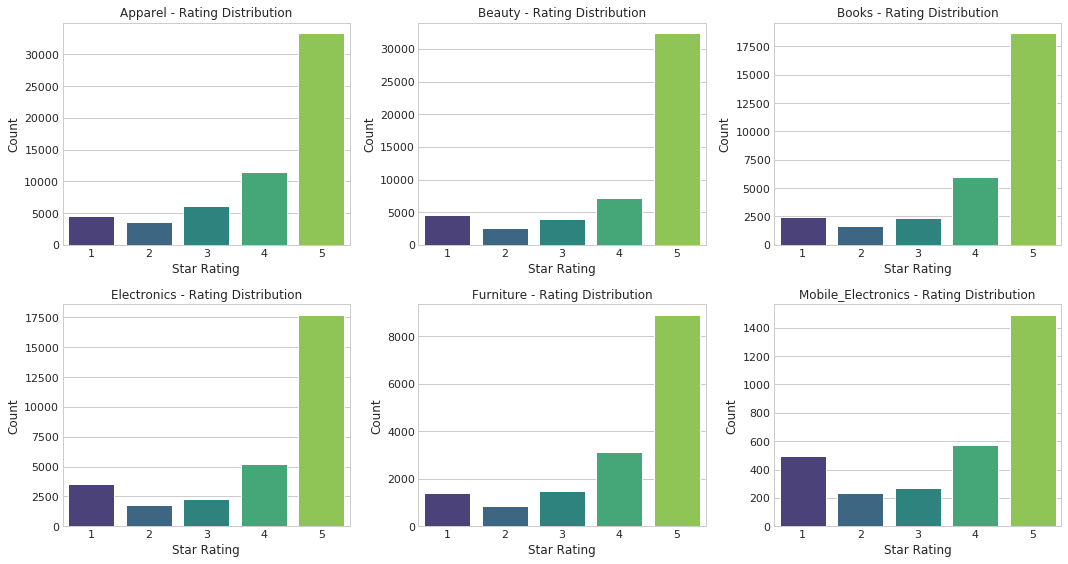

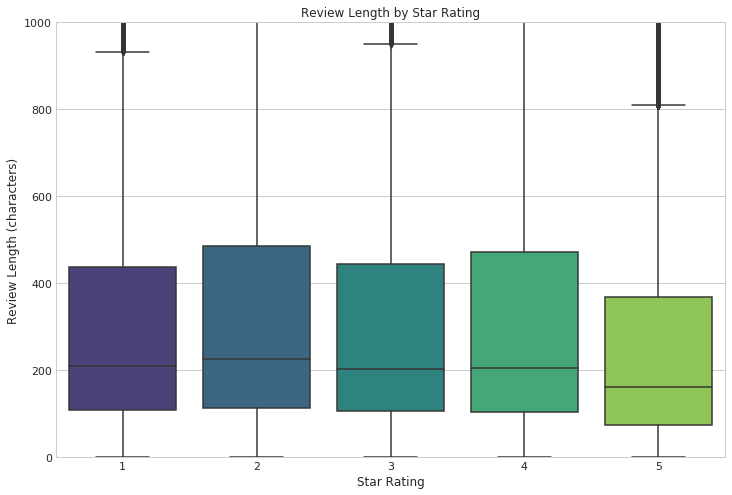

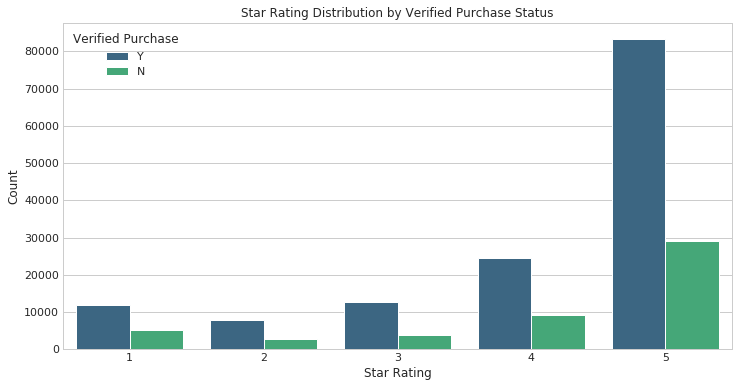

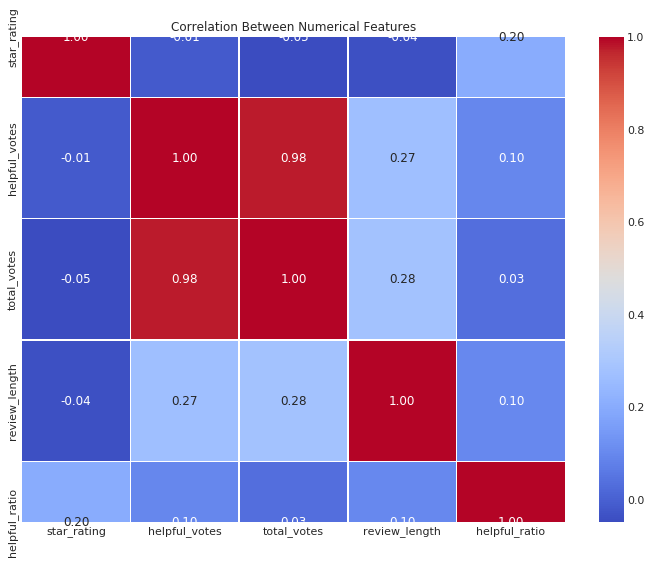

Copying file:///tmp/amazon_reviews_eda.png [Content-Type=image/png]...
Copying file:///tmp/category_rating_distributions.png [Content-Type=image/png]...
Copying file:///tmp/correlation_heatmap.png [Content-Type=image/png]...         
Copying file:///tmp/helpful_votes_by_category.png [Content-Type=image/png]...   
/ [4 files][174.4 KiB/174.4 KiB]                                                
==> NOTE: You are performing a sequence of gsutil operations that may
run significantly faster if you instead use gsutil -m cp ... Please
see the -m section under "gsutil help options" for further information
about when gsutil -m can be advantageous.

Copying file:///tmp/review_length_by_rating.png [Content-Type=image/png]...
Copying file:///tmp/verified_purchase_effect.png [Content-Type=image/png]...    
- [6 files][206.2 KiB/206.2 KiB]                                                
Operation completed over 6 objects/206.2 KiB.                                    


In [27]:
plt.style.use('seaborn-whitegrid')

# 1. Category-specific Rating Distributions
plt.figure(figsize=(15, 8))
for i, category in enumerate(categories, 1):
    plt.subplot(2, 3, i)
    sns.countplot(data=category_samples[category], x='star_rating', palette='viridis')
    plt.title(f"{category} - Rating Distribution")
    plt.xlabel('Star Rating')
    plt.ylabel('Count')
plt.tight_layout()
plt.savefig("/tmp/category_rating_distributions.png")
plt.show()

# 2. Review Length vs. Star Rating
plt.figure(figsize=(12, 8))
sns.boxplot(data=combined_sample, x='star_rating', y='review_length', palette='viridis')
plt.title('Review Length by Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('Review Length (characters)')
plt.ylim(0, 1000)  # Limit y-axis for better visualization
plt.savefig("/tmp/review_length_by_rating.png")
plt.show()

# 3. Verified Purchase Effect on Ratings
plt.figure(figsize=(12, 6))
sns.countplot(data=combined_sample, x='star_rating', hue='verified_purchase', palette='viridis')
plt.title('Star Rating Distribution by Verified Purchase Status')
plt.xlabel('Star Rating')
plt.ylabel('Count')
plt.legend(title='Verified Purchase')
plt.savefig("/tmp/verified_purchase_effect.png")
plt.show()


# 4. Correlation Heatmap of Numerical Features
plt.figure(figsize=(10, 8))
numerical_cols = ['star_rating', 'helpful_votes', 'total_votes', 'review_length', 'helpful_ratio']
corr = combined_sample[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Between Numerical Features')
plt.tight_layout()
plt.savefig("/tmp/correlation_heatmap.png")
plt.show()

# Save all visualizations to GCS
!gsutil cp /tmp/*.png gs://final-project-bucket-amazon/visualizations/

### Inference:
1. Category-Specific Rating Distributions
- Across all product categories, 5-star ratings dominate, reinforcing the positive bias in reviews.
- 1-star ratings are consistently lower, but some categories (e.g., Mobile Electronics) show a slightly higher percentage of low ratings, indicating potential dissatisfaction in specific product types.
2. Review Length vs. Star Rating
- Lower-rated reviews (1-2 stars) tend to be longer, suggesting that negative reviewers elaborate on their dissatisfaction.
- 5-star reviews are shorter on average, possibly due to brief positive affirmations (e.g., "Great product!").
3. Star Rating Distribution by Verified Purchase Status
- Verified purchases tend to have a higher proportion of 5-star ratings, indicating that people who actually buy the product rate it more positively.
- Unverified reviews have a more even spread, suggesting potential spam or biased reviews.
4. Correlation Heatmap of Numerical Features
- Strong correlation between helpful votes and total votes (0.98), which is expected since total votes include helpful votes.
- Weak correlation between star rating and helpful ratio (0.20) suggests that higher ratings do not necessarily mean more helpful reviews.
- Review length has a weak correlation with helpful votes (0.27), indicating that longer reviews may be more informative, but not necessarily more helpful.

### Final Conclusion:
1. The sampling method did not significantly alter trends, meaning the sample is representative of the full dataset.
2. Bias towards positive reviews is consistent across categories.
3. Negative reviews tend to be longer, possibly because dissatisfied customers explain issues in detail.
4. Verified purchase reviews are more positive, while unverified reviews are more spread out.
5. Helpful votes are more about engagement than star rating.

This analysis helps in understanding review trends and guides further sentiment analysis.